In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, roc_auc_score, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from utils import get_metrics, plot_roc_curve
import time

# load data
df = pd.read_csv('../data/amazon_preprocessed.csv')
x = df.drop(columns=['isBestSeller', 'title'])
y = df['isBestSeller'].astype(int) # binary classification 0 or 1

print(x.shape)
print(y.value_counts())


(1295313, 6)
isBestSeller
0    1286832
1       8481
Name: count, dtype: int64


In [2]:
# 80% of data to training, and 20% to testing
# x is features, and y is target labels
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify = y)

print(f"Training size: {x_train.shape}")
print(f"Testing size: {x_test.shape}")

Training size: (1036250, 6)
Testing size: (259063, 6)


In [3]:
# handle class imbalance
non_bestSellers = (y_train == 0).sum()
bestSellers = (y_train == 1).sum()
scale = non_bestSellers / bestSellers
print(f"Scale pos weight: {scale:.2f}")

# build xgboost model
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale,
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
)

start = time.time()
xgb_model.fit(x_train, y_train)
y_pred = xgb_model.predict(x_test)
xgb_time = time.time() - start

print(f"XGBoost Training Time: {xgb_time:.4f}s")


Scale pos weight: 151.73
XGBoost Training Time: 11.0467s


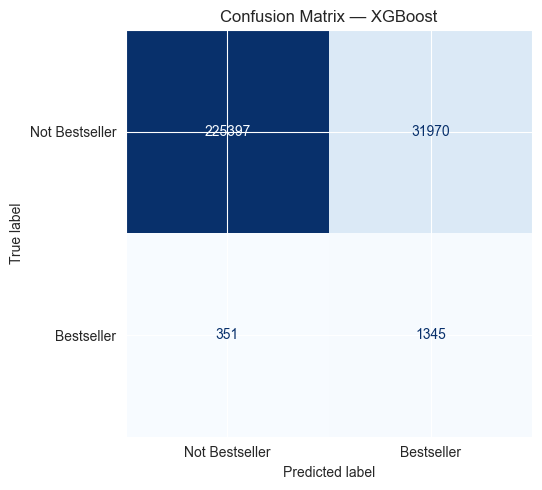

In [5]:
cm = confusion_matrix(y_test, y_pred)

display = ConfusionMatrixDisplay(
    confusion_matrix = cm,
    display_labels =["Not Bestseller", "Bestseller"]
)

fig,ax = plt.subplots(figsize=(6,5))
display.plot(ax=ax, colorbar= False, cmap="Blues")
ax.set_title("Confusion Matrix — XGBoost")
plt.tight_layout()
plt.show()

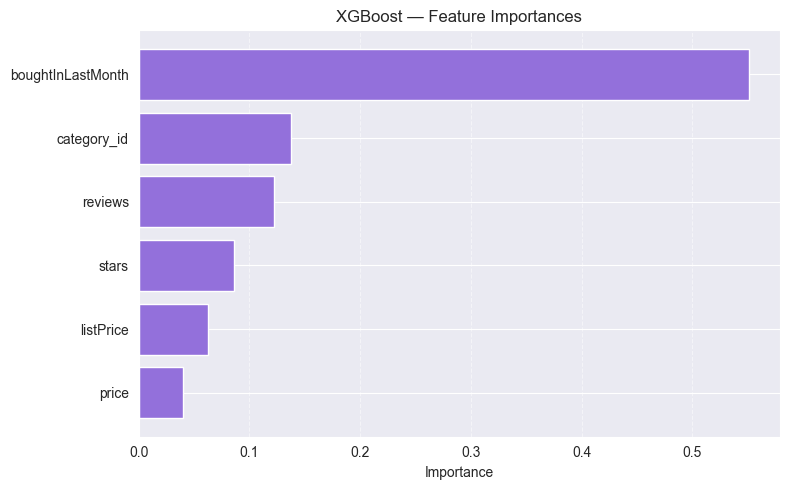

In [6]:
# feature importance
importance = xgb_model.feature_importances_
features = np.array(x.columns)

sorted_idx = np.argsort(importance)

plt.figure(figsize=(8,5))
plt.barh(features[sorted_idx], importance[sorted_idx], color='mediumpurple')
plt.title('XGBoost — Feature Importances')
plt.xlabel('Importance')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [7]:
import sys 
sys.path.append('..')
from utils import get_metrics

xgb_metrics = get_metrics(y_test, y_pred, "XGBoost")
#print(xgb_metrics)

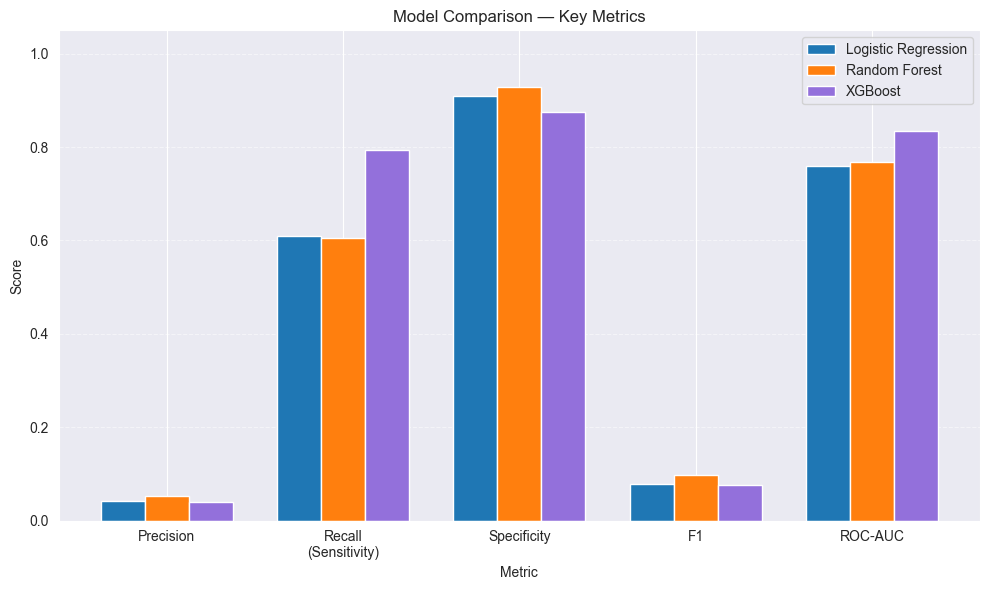

In [8]:
metrics = ['Precision', 'Recall\n(Sensitivity)', 'Specificity', 'F1', 'ROC-AUC']

lr_scores =  [0.0421, 0.6097, 0.9086, 0.0788, 0.7591]
rf_scores =  [0.0534, 0.6055, 0.9292, 0.0981, 0.7674]
xgb_scores = [xgb_metrics['precision'], xgb_metrics['recall'], 
              xgb_metrics['specificity'], xgb_metrics['f1'], 
              xgb_metrics['roc_auc']]

x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width, lr_scores, width, label='Logistic Regression')
ax.bar(x, rf_scores, width, label='Random Forest')
ax.bar(x + width, xgb_scores, width, label='XGBoost', color='mediumpurple')

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Key Metrics')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()